#### Eeg eye state
All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds.<br> The eye state was detected via a camera during the EEG measurement and added later manually to the file after analyzing the video frames. '1' indicates the eye-closed and '0' the eye-open state.<br> All values are in chronological order with the first measured value at the top of the data.<br>
Source: https://www.openml.org/search?type=data&sort=runs&status=active&id=1471

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


<h3><center>Loading and exploring the DS</h3>

In [66]:
# The file is in ARFF format, so I use scipy to load it
data, meta = arff.loadarff(r"EEG_Eye+State.csv")
df = pd.DataFrame(data)
df['eyeDetection'] = df['eyeDetection'].astype(int)
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [67]:
# i am gonna  create time index from the sampling rate.
sampling_rate = len(df)/117
df.insert(0, 'time_sec', np.arange(len(df))/sampling_rate)
# 117 seconds of recording, so the sampling rate is 14980/117 is almost 128 Hz

In [68]:
# Later I need to compare the original and optimized DSs.
df_original = df.copy()

In [69]:
df.info()
# 14980 rows, 15 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time_sec      14980 non-null  float64
 1   AF3           14980 non-null  float64
 2   F7            14980 non-null  float64
 3   F3            14980 non-null  float64
 4   FC5           14980 non-null  float64
 5   T7            14980 non-null  float64
 6   P7            14980 non-null  float64
 7   O1            14980 non-null  float64
 8   O2            14980 non-null  float64
 9   P8            14980 non-null  float64
 10  T8            14980 non-null  float64
 11  FC6           14980 non-null  float64
 12  F4            14980 non-null  float64
 13  F8            14980 non-null  float64
 14  AF4           14980 non-null  float64
 15  eyeDetection  14980 non-null  int32  
dtypes: float64(15), int32(1)
memory usage: 1.8 MB


### Finding issues in the DS:

In [70]:
df.duplicated().sum()

0

In [71]:
# Let's check the target value 
df['eyeDetection'].value_counts()
# the imblance is  not too bad. 

eyeDetection
0    8257
1    6723
Name: count, dtype: int64

In [72]:
df.describe()

,time_sec,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,58.496095,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832,0.448798
std,33.776118,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043,0.497388
min,0.000000,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000,0.000000
25%,29.248047,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,58.496095,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,87.744142,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,116.992190,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000,1.000000


In [73]:
# Let me check the range of each EEG channel
# From describe() above, most values are around 4000 to 4600.
signal_columns= [column for column in df.columns if column not in ['eyeDetection', 'time_sec']]
print("Min values:")
print(df[signal_columns].min().round(2))
print("\nMaxx values:")
print(df[signal_columns].max().round(2))

Min values:
AF3    1030.77
F7     2830.77
F3     1040.00
FC5    2453.33
T7     2089.74
P7     2768.21
O1     2086.15
O2     4567.18
P8     1357.95
T8     1816.41
FC6    3273.33
F4     2257.95
F8       86.67
AF4    1366.15
dtype: float64

Maxx values:
AF3    309231.00
F7       7804.62
F3       6880.51
FC5    642564.00
T7       6474.36
P7     362564.00
O1     567179.00
O2       7264.10
P8     265641.00
T8       6674.36
FC6      6823.08
F4       7002.56
F8     152308.00
AF4    715897.00
dtype: float64


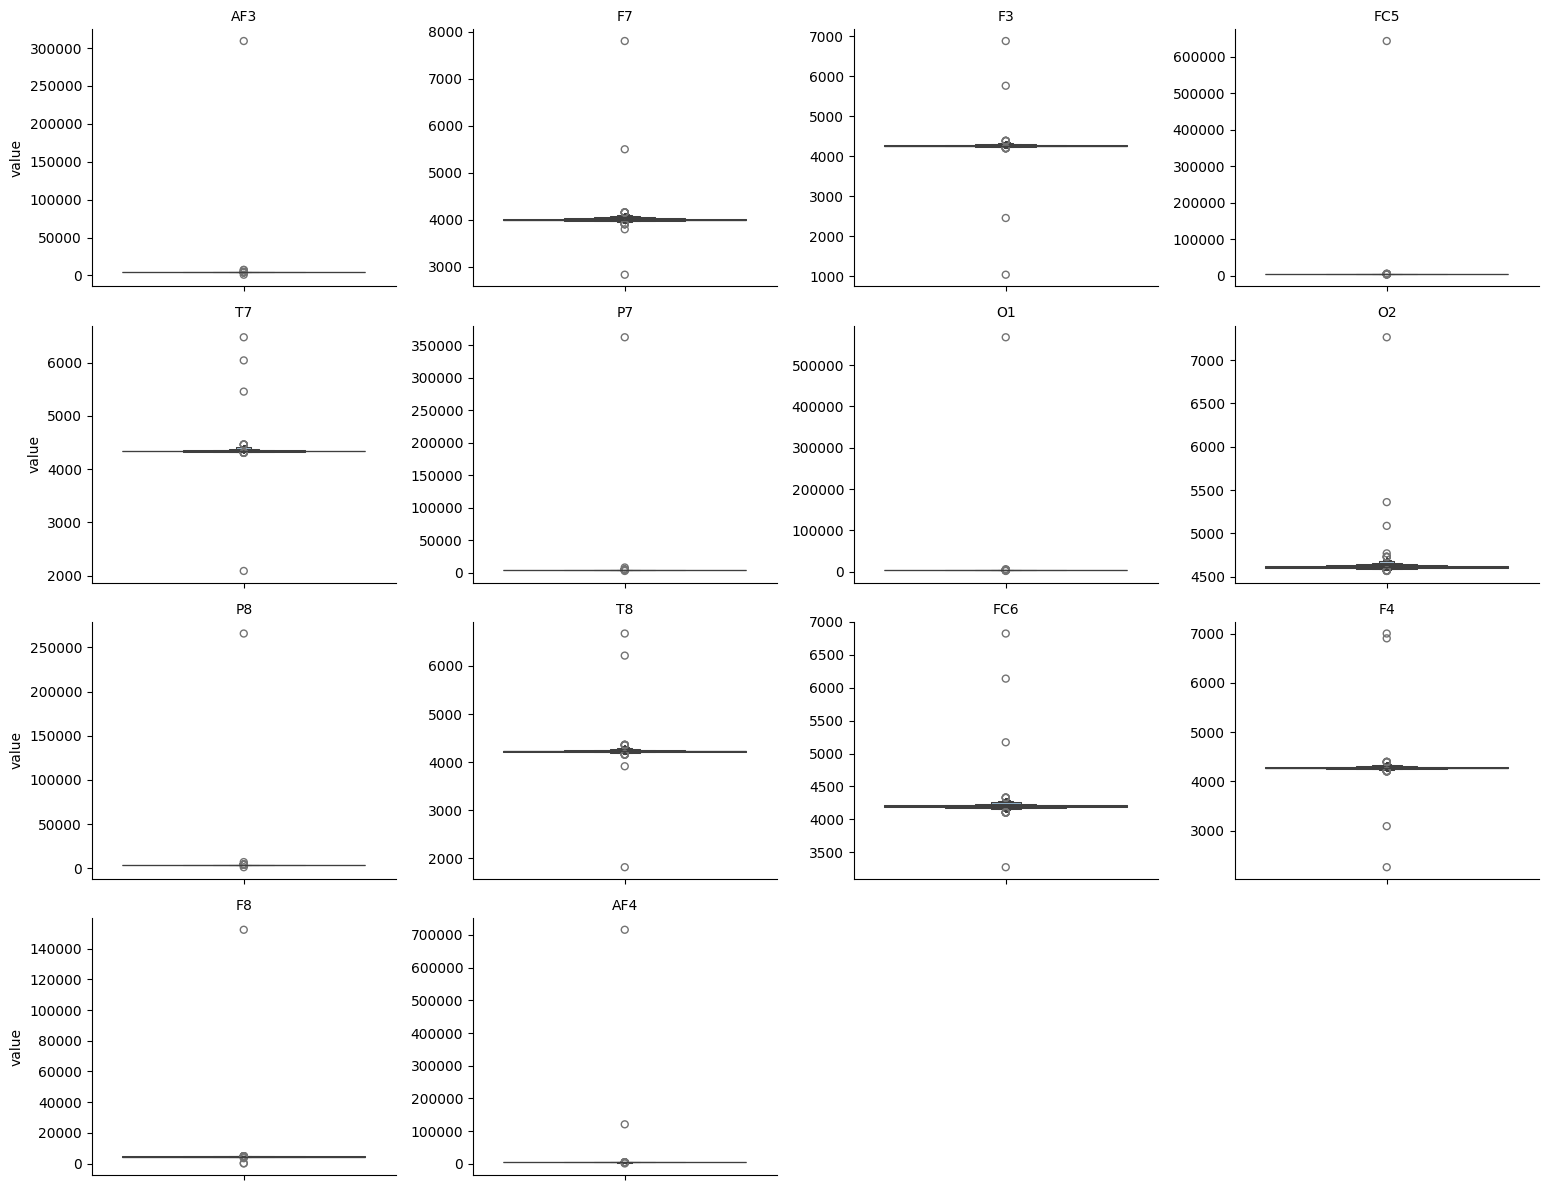

In [74]:
# Let me visualize the distribution of each channel.
columns = df[signal_columns].melt(var_name='channel', value_name='value')
g = sns.catplot(data=columns, y="value", col="channel", kind="boxen", col_wrap=4, sharey=False, height=3, aspect=1.3)
g.set_titles("{col_name}")
plt.show()

### Handling issues in the DS

In [75]:
# What I can see from above graphs: channels AF3, FC5, P7, O1, P8, F8, AF4 have extreme spikes.
# I need to find how many rows have extreme values.
# Values above 8000 or below 1000 are outliers. 
anomalies_mask =(df[signal_columns]>8000).any(axis=1)|(df[signal_columns] < 1000).any(axis=1)
print("Rows with anomaly values:",anomalies_mask.sum())

Rows with anomaly values: 4


In [76]:
# let's see what those rows look like.
df[anomalies_mask]

,time_sec,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
898,7.013752,7222.05,3797.95,1040.00,3733.85,6040.51,362564.00,6350.26,5361.54,1357.95,6215.38,3273.33,3091.28,276.4100,715897.00,0
10386,81.118959,7398.46,2830.77,2457.44,642564.00,6474.36,8092.31,567179.00,5087.69,7143.59,1816.41,6137.95,6904.62,3504.1000,121026.00,0
11509,89.890053,309231.00,5500.51,6880.51,5416.41,5454.87,4002.05,2086.15,4770.26,265641.00,3914.87,6823.08,2257.95,152308.0000,5022.56,1
13179,102.933445,1030.77,7804.62,5762.56,2453.33,2089.74,2768.21,3581.54,7264.10,4586.15,6674.36,5170.77,7002.56,86.6667,1366.15,0


In [77]:
# I have 4 rows with anamolous values, so I am going to drop them, because it is only 4 rows.
df = df[~anomalies_mask].reset_index(drop=True)

In [78]:
# Now I am going to use the IQR method to handle the rest of the outliers. 

q1 = df[signal_columns].quantile(0.25)
q3= df[signal_columns].quantile(0.75)
iqr = q3 - q1
lower = q1 - 3 *iqr
upper= q3 +3 *iqr

clipped = df[signal_columns].clip(lower=lower, upper=upper, axis=1)
df[signal_columns] = clipped
print(df[signal_columns].max().round(2))

AF3    4405.63
F7     4120.01
F3     4332.30
FC5    4204.61
T7     4393.35
P7     4671.31
O1     4160.51
O2     4682.54
P8     4264.61
T8     4296.43
FC6    4274.34
F4     4345.65
F8     4697.45
AF4    4465.13
dtype: float64


In [79]:
# Good, The values looks good now
# Let's check again shape and the distribution.
print(f"Shape:{df.shape}")
df.describe()

Shape:(14976, 16)


,time_sec,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.00000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000,14976.000000
mean,58.492958,4300.574386,4009.421569,4263.685912,4122.273878,4340.994653,4619.363784,4072.797764,4615.594125,4201.10608,4230.886423,4201.736610,4278.843649,4605.683334,4360.702575,0.448851
std,33.774577,34.958463,29.739101,19.731194,20.449476,14.465366,15.409707,20.798275,17.451136,16.75811,18.363786,22.635736,19.048067,30.264846,36.043729,0.497394
min,0.000000,4197.950000,3905.640000,4197.440000,4058.460000,4304.620000,4567.150000,4026.150000,4567.180000,4147.69000,4163.570000,4127.200000,4209.220000,4510.760000,4249.740000,0.000000
25%,29.248047,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.77000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,58.488284,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.49000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,87.736332,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.23000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,116.992190,4405.630000,4120.010000,4332.300000,4204.610000,4393.350000,4671.310000,4160.510000,4682.540000,4264.61000,4296.430000,4274.340000,4345.650000,4697.450000,4465.130000,1.000000


<h3><center>Feature engineering<h3>

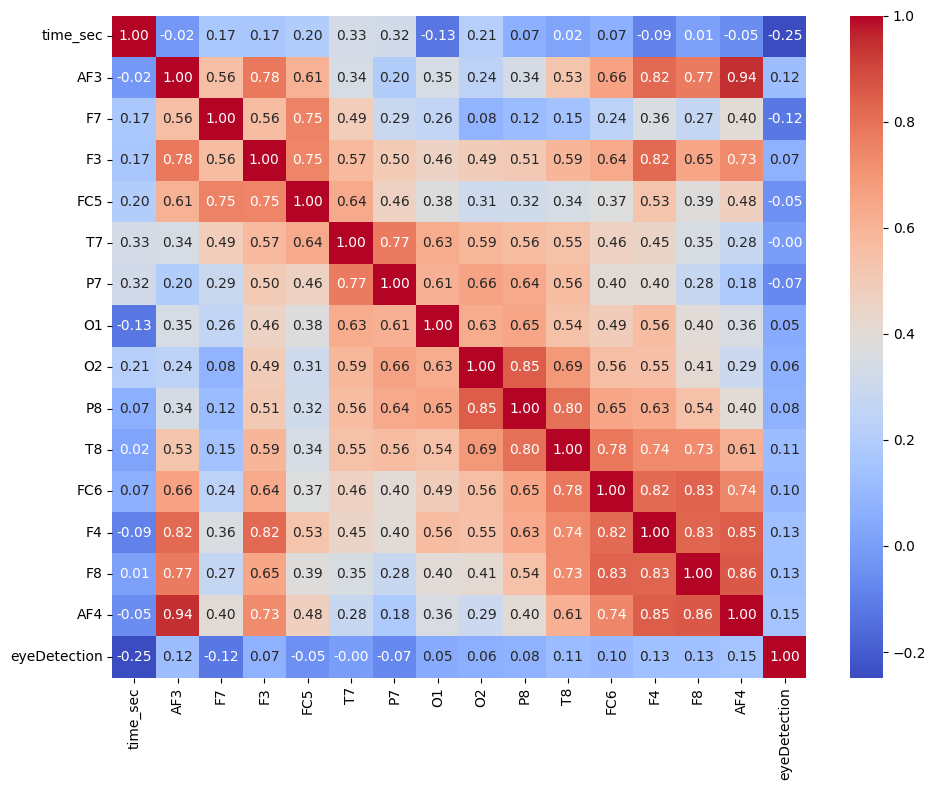

In [80]:
# Let's check the correlation between channels and the target to understand
# which channels separate eye open vs closedd.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

In [81]:
# I can see that many columns have high correlation with each other. 
# AF3/4, P8/7, F8 and FC5 have almost perfect correlation with each other.
# This means redundancy. Some channels carry almost the same information.
# Correlations with eyeDetection are lowm the highest one is 0.15


# let's find the  midpoint between the two class medians 

signal_columns = df.columns.drop('eyeDetection')
medians = df.groupby('eyeDetection')[signal_columns].median()

gap =(medians.loc[1]-medians.loc[0]).abs().sort_values(ascending=False)
border = ((medians.loc[0]+medians.loc[1])/2).round(2)

summary = pd.DataFrame({'open':medians.loc[0].round(2),'closed':medians.loc[1].round(2),'border':border,'gap':gap.round(2)}).sort_values('gap', ascending=False)
summary
# AF3, AF4, F3, F4 and FC6 go up when eyes close
# F7 goes down when eyes close.
# For debugging, I used QWEB MAX 3 

,open,closed,border,gap
time_sec,75.69,53.51,64.60,22.19
AF4,4352.31,4360.00,4356.16,7.69
AF3,4291.28,4297.95,4294.62,6.67
F8,4601.03,4606.67,4603.85,5.64
F4,4274.87,4278.97,4276.92,4.10
F7,4007.18,4003.59,4005.38,3.59
P7,4619.49,4615.90,4617.70,3.59
FC6,4199.49,4202.05,4200.77,2.56
T8,4228.21,4230.77,4229.49,2.56
F3,4261.54,4263.59,4262.57,2.05


### Noise and Overlap

In [82]:
# In previous cell, there are three columns with very low gap
# I am gonna drop them
df = df.drop(['T7', 'FC5','P8',  'O1'], axis=1)
df.shape

(14976, 12)

In [83]:
# Now let me handle the redundancy between the columns 
# I am going to combine high related columns.
df['frontal_af']= (df['AF3']+ df['AF4']) /2
df['frontal_right'] = (df['F4'] + df['F8']) /2
df = df.drop(['AF3', 'AF4', 'F4', 'F8'], axis=1)
# I used gpt to for grouping the columns. 
#  Anterior Frontal = AF3 + AF4
#  This is the very front of your forehead It is  right above your eyebrows.
# Frontal Right = F4 + F8:
# This is the front right side of your head, near your temple.

In [84]:
df.columns

Index(['time_sec', 'F7', 'F3', 'P7', 'O2', 'T8', 'FC6', 'eyeDetection',
       'frontal_af', 'frontal_right'],
      dtype='object')

In [85]:
# The time second is just time index, that is not a real feature. 
X = df.drop(['eyeDetection', 'time_sec'], axis=1)
y = df['eyeDetection']

random_forest_model = RandomForestClassifier(n_estimators=200, random_state=42,  n_jobs=-1)
random_forest_model.fit(X, y)
importance= pd.Series(random_forest_model.feature_importances_,index=X.columns).sort_values()
print("feature importance:")
print(importance.round(3))

feature importance:
F3               0.097
O2               0.101
T8               0.102
FC6              0.114
frontal_right    0.131
P7               0.148
F7               0.152
frontal_af       0.156
dtype: float64


In [86]:
# Splitting the data into training and testing sets
split_point = int(0.8 * len(df))
print(f"Train:{split_point} samples (0 to {df['time_sec'].iloc[split_point-1]:.1f}s)")
print(f"Test:{len(df)-split_point} samples ({df['time_sec'].iloc[split_point]:.1f}s to {df['time_sec'].iloc[-1]:.1f}s)")
# For debugging, I used QWEB MAX 3.

Train:11980 samples (0 to 93.6s)
Test:2996 samples (93.6s to 117.0s)


In [87]:
X_train = df.iloc[:split_point][X.columns]
X_test= df.iloc[split_point:][X.columns]
y_train = df.iloc[:split_point]['eyeDetection']
y_test = df.iloc[split_point:]['eyeDetection']

print(f"Train class balance:\n{y_train.value_counts()}")
print(f"\nTest class balance:\n{y_test.value_counts()}")

Train class balance:
eyeDetection
1    6441
0    5539
Name: count, dtype: int64

Test class balance:
eyeDetection
0    2715
1     281
Name: count, dtype: int64


In [88]:
# # Test ds is very imbalanced: 2715 open vs 281 closed.
# I am going to use class_weight to handle the imbalance.
Random_Forest_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
Random_Forest_model.fit(X_train, y_train)
classes = Random_Forest_model.predict(X_test)

print(classification_report(y_test, classes,target_names=['Open', 'Closed']))

              precision    recall  f1-score   support

        Open       0.89      0.46      0.60      2715
      Closed       0.08      0.46      0.14       281

    accuracy                           0.46      2996
   macro avg       0.49      0.46      0.37      2996
weighted avg       0.82      0.46      0.56      2996



In [89]:
# the result is too bad, metrics for closed class are very bad. 
# I am gonna use rolling mean and rolling std over second window, I am gonna use different window samples to find the best one
# to find how much the signal changes 
# Source: 
# https://pandas.pydata.org/pandas-docs/version/2.2/reference/api/pandas.core.window.rolling.Rolling.std.html

base_features = df.drop(['eyeDetection', 'time_sec'], axis=1)
target= df['eyeDetection']
window_size = 64 
# For each channel, I am going to calculate average and spreed. 
rolling_mean = base_features.rolling(window_size, min_periods=1).mean().add_suffix('_mean')
rolling_std = base_features.rolling(window_size, min_periods=1).std(ddof=0).add_suffix('_std')

# Combining the features and rolling variables.
features= pd.concat([rolling_mean, rolling_std], axis=1)

# Splitting the ds into training and testing again. 
X_train, X_test = features.iloc[:split_point], features.iloc[split_point:]
y_train, y_test =target.iloc[:split_point], target.iloc[split_point:]

Random_Forest_model.fit(X_train, y_train)
y_predicted= Random_Forest_model.predict(X_test)
print(classification_report(y_test, y_predicted, target_names=['Open', 'Closed']))

              precision    recall  f1-score   support

        Open       0.89      0.56      0.69      2715
      Closed       0.07      0.31      0.11       281

    accuracy                           0.54      2996
   macro avg       0.48      0.43      0.40      2996
weighted avg       0.81      0.54      0.63      2996



In [90]:
# It is better than before, but still not good. 
# # Let me also try  stratified random split for comparison.

X_random = df[base_features.columns]
y_random= df['eyeDetection']
X_train, X_test, y_train, y_test= train_test_split(X_random, y_random,test_size=0.2, random_state=42, stratify=y_random)


random_forest_model.fit(X_train, y_train)
y_prediction= random_forest_model.predict(X_test)

print("Stratified randum split:")
print(classification_report(y_test, y_prediction, target_names=['Open', 'Closed']))

Stratified randum split:
              precision    recall  f1-score   support

        Open       0.87      0.91      0.89      1651
      Closed       0.88      0.83      0.86      1345

    accuracy                           0.88      2996
   macro avg       0.88      0.87      0.87      2996
weighted avg       0.88      0.88      0.88      2996



In [ ]:
# Interesting, stratified split gives better results than two previous.

In [103]:
# feature importance from the stratified split: 
importance_v2 = pd.Series(random_forest_model.feature_importances_, index=base_features.columns).sort_values()
print("Feature importance:")
print(importance_v2.round(3))

Feature importance:
F3               0.095
O2               0.103
T8               0.103
FC6              0.111
frontal_right    0.132
P7               0.151
F7               0.152
frontal_af       0.154
dtype: float64


In [92]:
df_optimized = df.copy()

<h3><center>Comparing original vs optimized DSs<h3>

In [93]:
# Let me compare the original vs optimized ds.
common_columns= [column for column in signal_columns if column in df_optimized.columns]

compare = (df_original[common_columns].agg(['mean', 'median', 'std', 'var']).T.add_suffix('_before')
           .join(df_optimized[common_columns].agg(['mean', 'median', 'std', 'var']).T.add_suffix('_after')).round(2))
compare

,mean_before,median_before,std_before,var_before,mean_after,median_after,std_after,var_after
time_sec,58.50,58.50,33.78,1140.83,58.49,58.49,33.77,1140.72
F7,4009.77,4005.64,45.94,2110.64,4009.42,4005.64,29.74,884.41
F3,4264.02,4262.56,44.43,1973.85,4263.69,4262.56,19.73,389.32
P7,4644.02,4617.95,2924.79,8554393.84,4619.36,4617.95,15.41,237.46
O2,4616.06,4613.33,29.29,858.06,4615.59,4613.33,17.45,304.54
T8,4231.32,4229.23,38.05,1447.87,4230.89,4229.23,18.36,337.23
FC6,4202.46,4200.51,37.79,1427.78,4201.74,4200.51,22.64,512.38


In [102]:
# comparison: describe() for original vs optimized 
print("Original dataset: \n")
print(df_original[common_columns].describe().round(2))
print("\nOptimized dataset: \n")
print(df_optimized[common_columns].describe().round(2))

Original dataset: 

       time_sec        F7        F3         P7        O2        T8       FC6
count  14980.00  14980.00  14980.00   14980.00  14980.00  14980.00  14980.00
mean      58.50   4009.77   4264.02    4644.02   4616.06   4231.32   4202.46
std       33.78     45.94     44.43    2924.79     29.29     38.05     37.79
min        0.00   2830.77   1040.00    2768.21   4567.18   1816.41   3273.33
25%       29.25   3990.77   4250.26    4611.79   4604.62   4220.51   4190.26
50%       58.50   4005.64   4262.56    4617.95   4613.33   4229.23   4200.51
75%       87.74   4023.08   4270.77    4626.67   4624.10   4239.49   4211.28
max      116.99   7804.62   6880.51  362564.00   7264.10   6674.36   6823.08

Optimized dataset: 

       time_sec        F7        F3        P7        O2        T8       FC6
count  14976.00  14976.00  14976.00  14976.00  14976.00  14976.00  14976.00
mean      58.49   4009.42   4263.69   4619.36   4615.59   4230.89   4201.74
std       33.77     29.74     19.73  

In [ ]:
# What I can see from above, the optimized ds has better distribution,  I removed : anaomalous, redundant and low gap channels.
# Rolling features gave better results but still not good.
#  Stratified split gave better results than two previous.